# Parcial 2022 — RESUELTO

**Solución de referencia** generada y verificada por Claude (5/7/2026), ejecutada con el entorno `apst`.

**Cómo usarla:** primero intentá resolver el ejercicio vos (cronometrado), después compará. Las celdas **💬 Discusión** son plantillas del tipo de comentario que el parcial espera en cada parte — en el parcial, cada parte sin comentario son puntos perdidos.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import astsadata as astsa
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

plt.rcParams['figure.figsize'] = [15, 5]
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.constrained_layout.use'] = True

In [2]:
## Funciones útiles del curso (en 2024 y 2025 vinieron incluidas en el enunciado)

def ccf(x, y, max_lag, ax=None, **kwargs):
    lags = np.arange(-max_lag, max_lag + 1)
    backwards = sm.tsa.ccf(x[::-1], y[::-1], adjusted=False)[max_lag::-1]
    forwards = sm.tsa.ccf(x, y, adjusted=False)[:max_lag + 1]
    ccf = np.r_[backwards[:-1], forwards]
    if ax is None:
        ax = plt.gca()
    ax.stem(lags, ccf, basefmt='k')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    conf_level = 1.96 / np.sqrt(x.shape[0])
    ax.fill_between(lags, conf_level, -conf_level, alpha=0.25)
    ax.set_xlabel('LAG')
    ax.set_ylabel('CCF')
    return ax

def periodogram(x, sampling_frequency=1):
    n = x.size
    P = 4/n**2 * np.abs(np.fft.fft(x))**2
    P = P[0:round(n/2)]
    f = np.arange(0, round(n/2))/n * sampling_frequency
    plt.plot(f, P)
    plt.xlabel('Frequency')
    plt.ylabel('Power')

def spectrum(x, sampling_frequency=1, nfreq=10):
    n = x.size
    nfreq = np.minimum(nfreq, round(n/2))
    P = 4/n**2 * np.abs(np.fft.fft(x))**2
    P = P[0:round(n/2)]
    f = np.arange(0, round(n/2))/n * sampling_frequency
    index = np.argsort(P)[::-1]
    return pd.DataFrame({'Frecuencia': f[index[0:nfreq]], 'Potencia': P[index[0:nfreq]]})

---
## Ejercicio 1 — `cardox`: tendencia + estacionalidad (Tipo A)

Serie mensual de CO₂ en Mauna Loa. Se pide: (1) tendencia lineal, (2) agregar término cuadrático, (3) periodograma de los residuos, (4) regresión con tendencia + componentes estacionales, (5) discutir residuos.

### 1.1 Ajuste de tendencia lineal

In [3]:
x = astsa.cardox.squeeze()   # DataFrame de 1 columna -> Series (mensual, 1958-2018)
n = len(x)
df = pd.DataFrame({'y': x.values, 't': np.arange(n)})

fit_lin = ols('y ~ t', data=df).fit()
print(fit_lin.summary().tables[1])
print()
print(f'R2 = {fit_lin.rsquared:.4f} | AIC = {fit_lin.aic:.1f}')

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    306.7089      0.306   1003.799      0.000     306.109     307.309
t              0.1293      0.001    177.976      0.000       0.128       0.131

R2 = 0.9776 | AIC = 4138.4


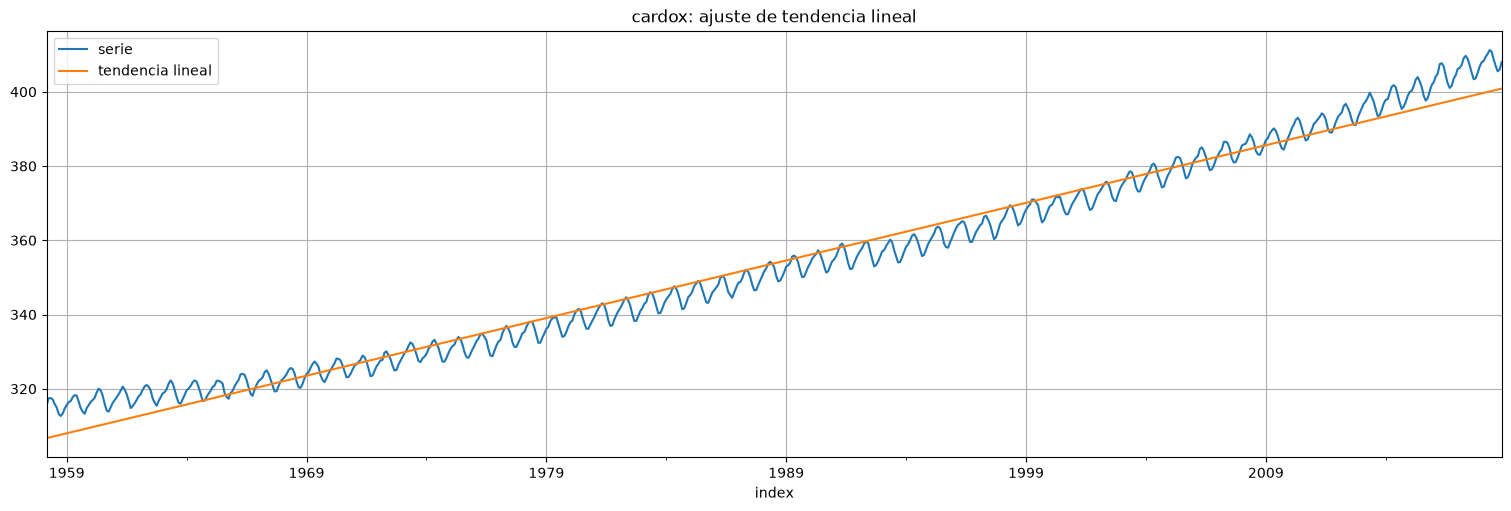

In [4]:
ax = x.plot(label='serie')
pd.Series(fit_lin.fittedvalues.values, index=x.index).plot(ax=ax, label='tendencia lineal')
ax.legend()
ax.set_title('cardox: ajuste de tendencia lineal');

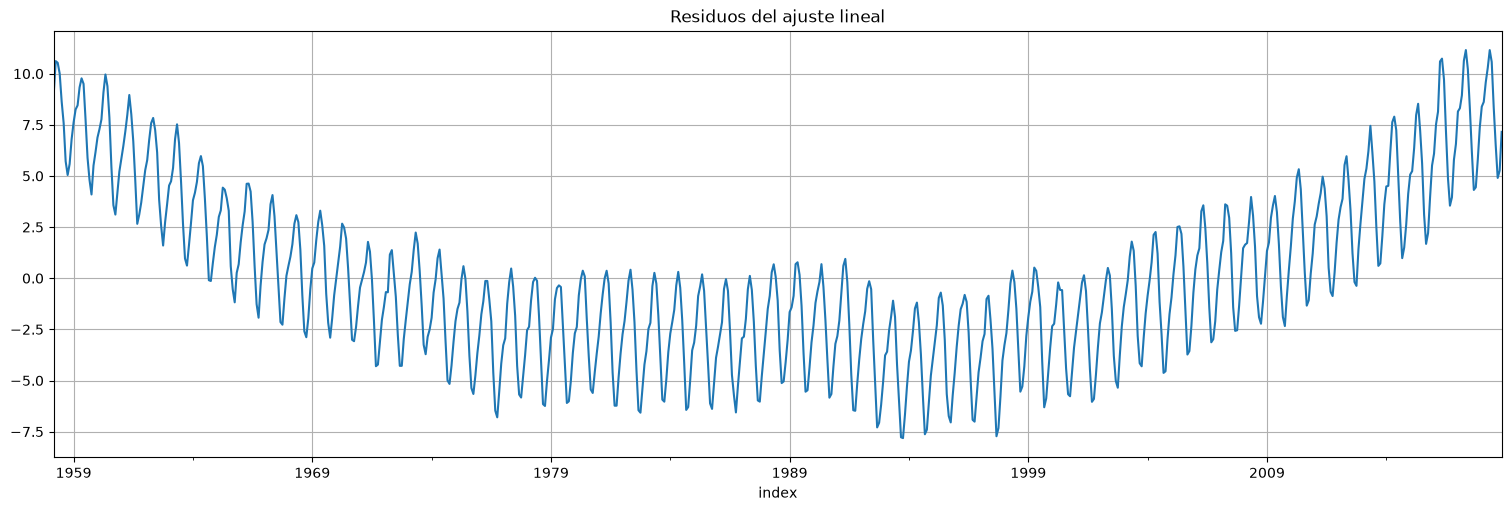

In [5]:
pd.Series(fit_lin.resid.values, index=x.index).plot(title='Residuos del ajuste lineal');

**💬 Discusión 1.1** — La pendiente es positiva y muy significativa (p < 0.001) y el R² es alto porque la serie está dominada por el crecimiento. Sin embargo el ajuste **no es adecuado**: los residuos muestran una **curvatura sistemática** (positivos en los extremos, negativos en el centro), señal de que el crecimiento del CO₂ es **acelerado** (más que lineal). Además queda a la vista la oscilación estacional que la tendencia no captura.

### 1.2 Tendencia cuadrática

In [6]:
fit_cuad = ols('y ~ t + I(t**2)', data=df).fit()
print(fit_cuad.summary().tables[1])
print()
print(f'R2 lineal     = {fit_lin.rsquared:.4f} | AIC = {fit_lin.aic:.1f}')
print(f'R2 cuadratico = {fit_cuad.rsquared:.4f} | AIC = {fit_cuad.aic:.1f}')

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    314.4597      0.245   1280.898      0.000     313.978     314.942
t              0.0654      0.002     41.964      0.000       0.062       0.068
I(t ** 2)   8.787e-05   2.07e-06     42.416      0.000    8.38e-05    9.19e-05

R2 lineal     = 0.9776 | AIC = 4138.4
R2 cuadratico = 0.9935 | AIC = 3231.7


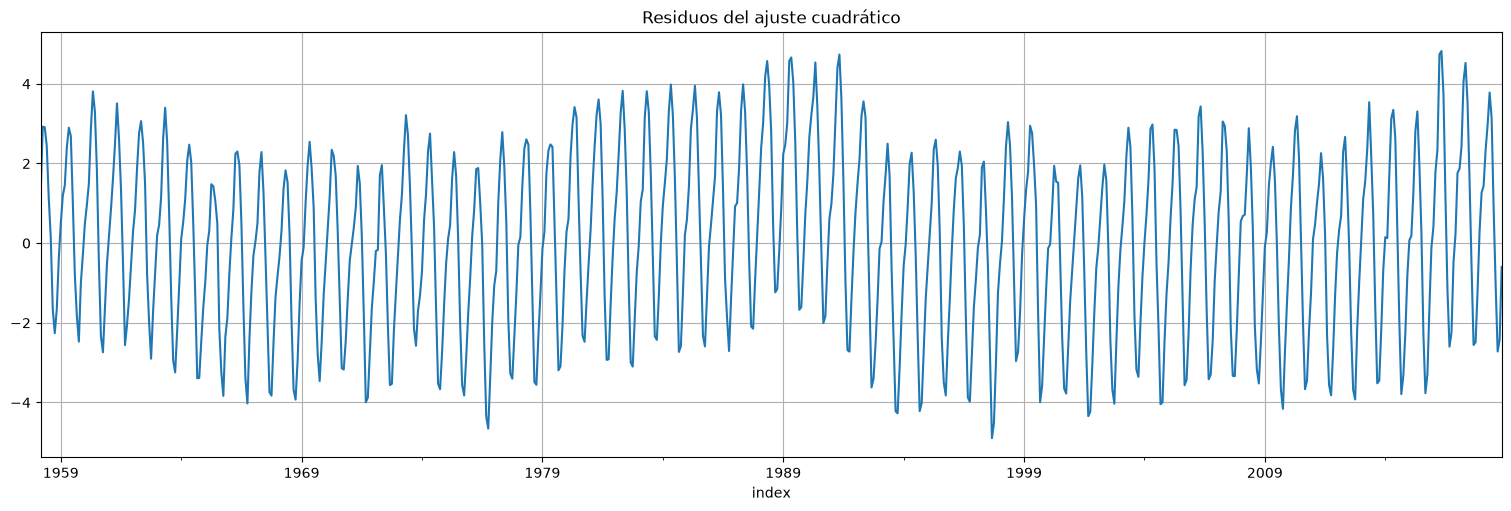

In [7]:
pd.Series(fit_cuad.resid.values, index=x.index).plot(title='Residuos del ajuste cuadrático');

**💬 Discusión 1.2** — El término cuadrático es **significativo** (p < 0.001) y el modelo **mejora**: sube el R² y baja el AIC. Los residuos ya no muestran curvatura sistemática — la tendencia queda bien capturada — pero persiste una **oscilación periódica regular** (la estacionalidad anual), que es lo que atacamos en las partes siguientes.

### 1.3 Periodograma de los residuos

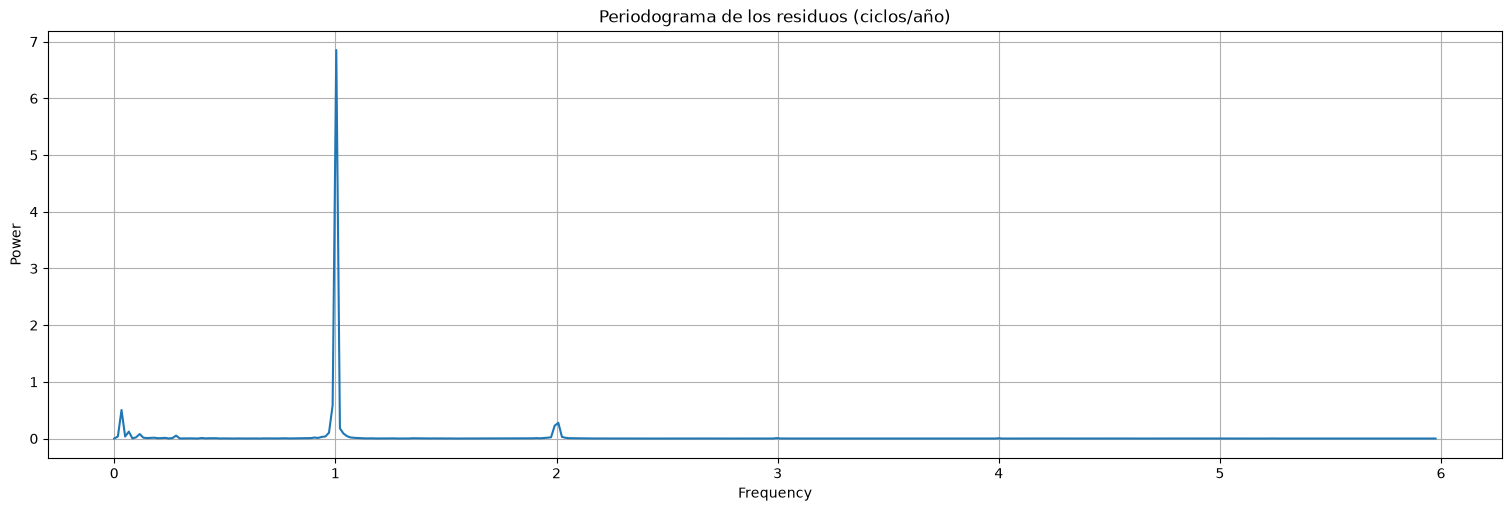

In [8]:
res = fit_cuad.resid
periodogram(res, sampling_frequency=12)   # 12 obs/año -> frecuencias en ciclos por año
plt.title('Periodograma de los residuos (ciclos/año)');

In [9]:
spectrum(res, sampling_frequency=12, nfreq=6)

,Frecuencia,Potencia
0,1.004115,6.851430
1,0.987654,0.587196
2,0.032922,0.503610
3,2.008230,0.276524
4,1.991770,0.226001
5,1.020576,0.177790


**💬 Discusión 1.3** — El periodograma muestra un **pico dominante en frecuencia 1 ciclo/año** (período 12 meses: el ciclo anual del CO₂) y un pico menor en el **armónico de 2 ciclos/año** (semestral), que aparece porque la forma de la onda anual no es una sinusoide perfecta. Eso sugiere incluir en la regresión términos sin/cos de frecuencia anual y semestral.

### 1.4 Regresión con tendencia + componentes estacionales

In [10]:
# Armónicos: para datos mensuales, frecuencia anual = 2*pi*t/12, semestral = 2*pi*2*t/12
df['sin1'] = np.sin(2*np.pi*df['t']/12)
df['cos1'] = np.cos(2*np.pi*df['t']/12)
df['sin2'] = np.sin(2*np.pi*2*df['t']/12)
df['cos2'] = np.cos(2*np.pi*2*df['t']/12)

fit_prev = ols('y ~ t + I(t**2) + sin1 + cos1 + sin2 + cos2', data=df).fit()
print(fit_prev.summary().tables[1])
print()

# sin2 no resulta significativo (p ~ 0.22): lo eliminamos y reajustamos
fit_full = ols('y ~ t + I(t**2) + sin1 + cos1 + cos2', data=df).fit()
print(fit_full.summary().tables[1])
print()
print(f'R2 = {fit_full.rsquared:.4f} | AIC = {fit_full.aic:.1f}')

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    314.4273      0.085   3704.297      0.000     314.261     314.594
t              0.0655      0.001    121.541      0.000       0.064       0.067
I(t ** 2)   8.786e-05   7.16e-07    122.668      0.000    8.65e-05    8.93e-05
sin1           1.6597      0.040     41.338      0.000       1.581       1.739
cos1           2.2824      0.040     56.926      0.000       2.204       2.361
sin2           0.0494      0.040      1.232      0.218      -0.029       0.128
cos2          -0.7856      0.040    -19.582      0.000      -0.864      -0.707

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    314.4280      0.085   3703.061      0.000     314.261     314.595
t              0.0655      0.001    121.492      0.

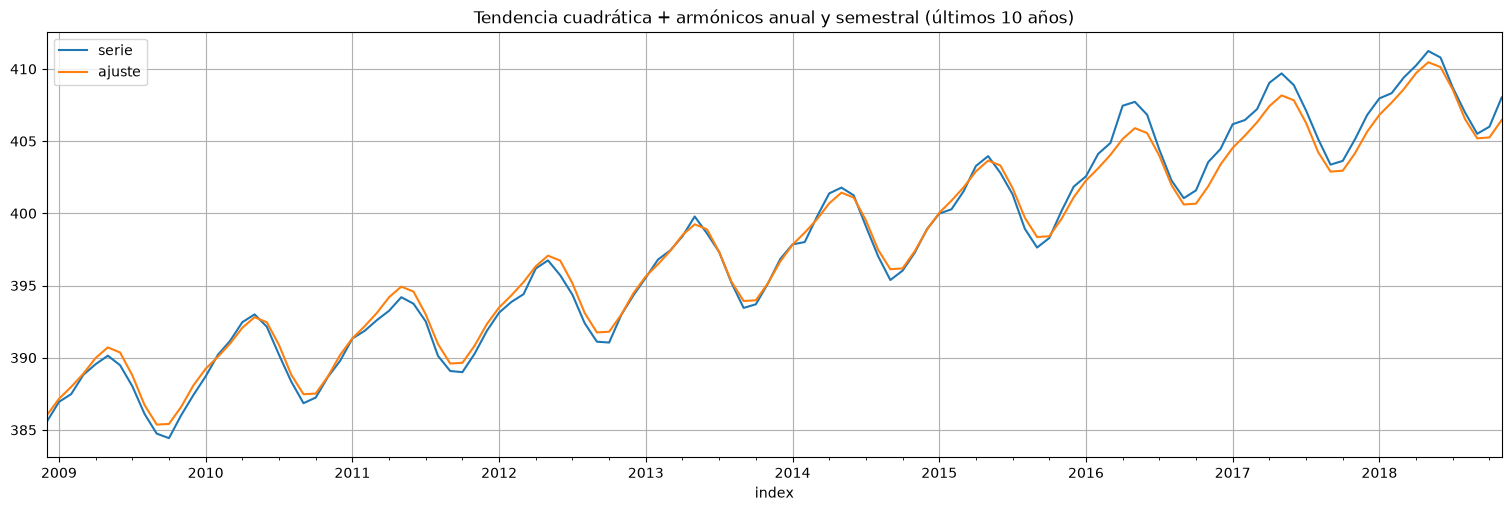

In [11]:
# Zoom a los últimos 10 años para ver la calidad del ajuste estacional
ajuste = pd.Series(fit_full.fittedvalues.values, index=x.index)
ax = x[-120:].plot(label='serie')
ajuste[-120:].plot(ax=ax, label='ajuste')
ax.legend()
ax.set_title('Tendencia cuadrática + armónicos anual y semestral (últimos 10 años)');

**💬 Discusión 1.4** — En el primer ajuste todos los términos son significativos **excepto `sin2`** (p ≈ 0.22): lo eliminamos y reajustamos. Declarar que se quitan los términos no significativos es parte de la respuesta esperada (el parcial 2024 lo pide explícitamente: *"elimine las variables no significativas"*). El modelo final — tendencia cuadrática + armónico anual (sin y cos) + coseno semestral — alcanza R² ≈ 0.999 y sigue de cerca el nivel y el ciclo anual. Alternativa igualmente válida: variables **dummy mensuales** (`C(mes)` en la fórmula) en lugar de armónicos, a costa de usar más parámetros (11 vs 3).

### 1.5 Residuos finales: ¿queda información?

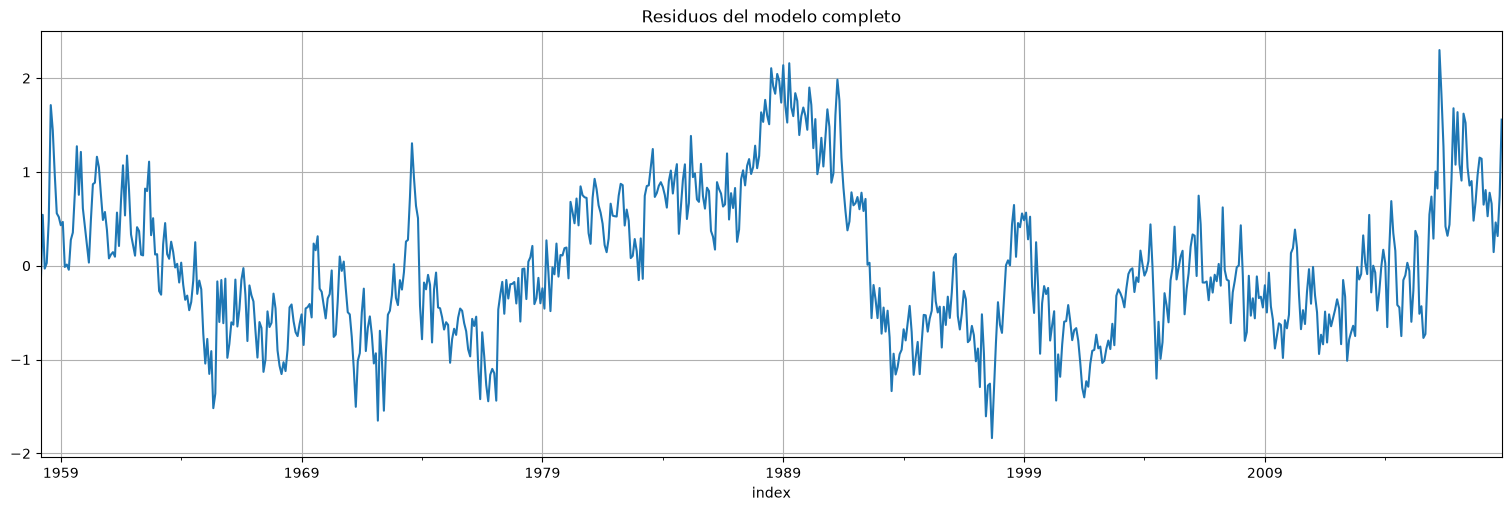

In [12]:
res_full = pd.Series(fit_full.resid.values, index=x.index)
res_full.plot(title='Residuos del modelo completo');

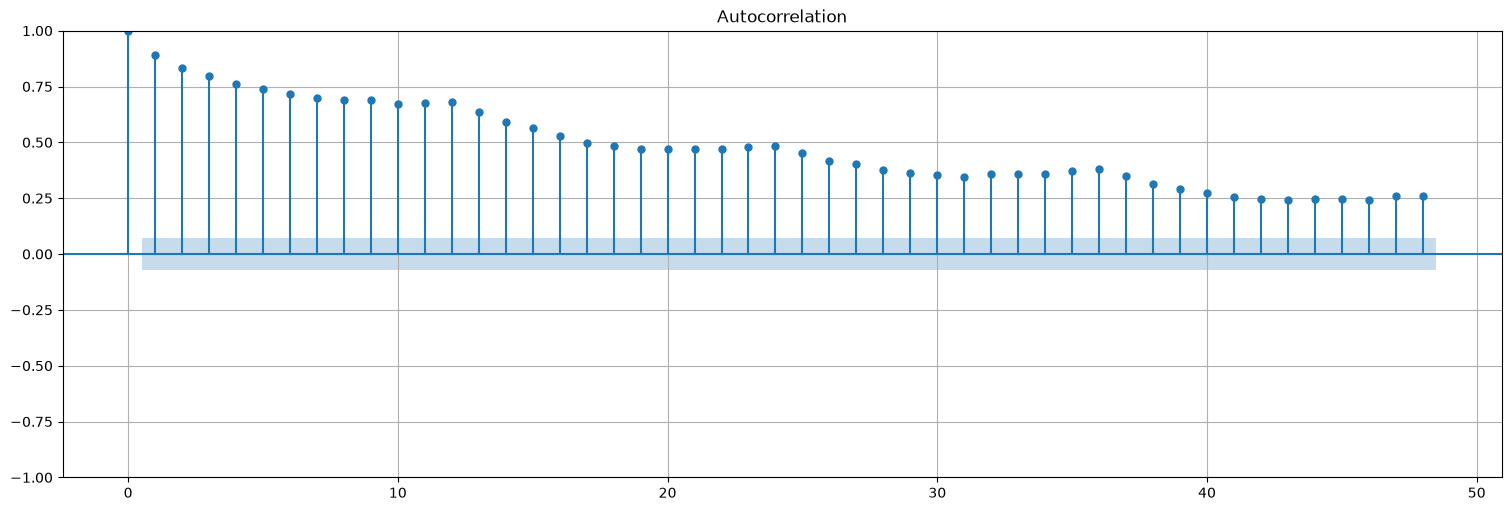

In [13]:
plot_acf(res_full, lags=48, bartlett_confint=False);

**💬 Discusión 1.5** — La varianza residual es mucho menor que al inicio, pero los residuos **no son ruido blanco**: la ACF muestra autocorrelación positiva fuerte y de decaimiento lento en los primeros lags. Es decir, **sí queda información por extraer** — dependencia serial de corto plazo que podría modelarse con un proceso ARMA sobre los residuos (no se pide hacerlo). Conclusión tipo para el parcial: *"el modelo de regresión captura tendencia y estacionalidad, pero los residuos conservan correlación serial, por lo que aún no son ruido blanco"*.

---
## Ejercicio 2 — `Nile`: modelo ARMA (Tipo B)

Flujo anual del Nilo en Asuán (1871–1970). Se pide: (1) ¿estacionaria?, (2) ACF/PACF, (3) ajustar ARMA(p,q) (puede comparar dos), (4) residuos, (5) predicción a 5 años.

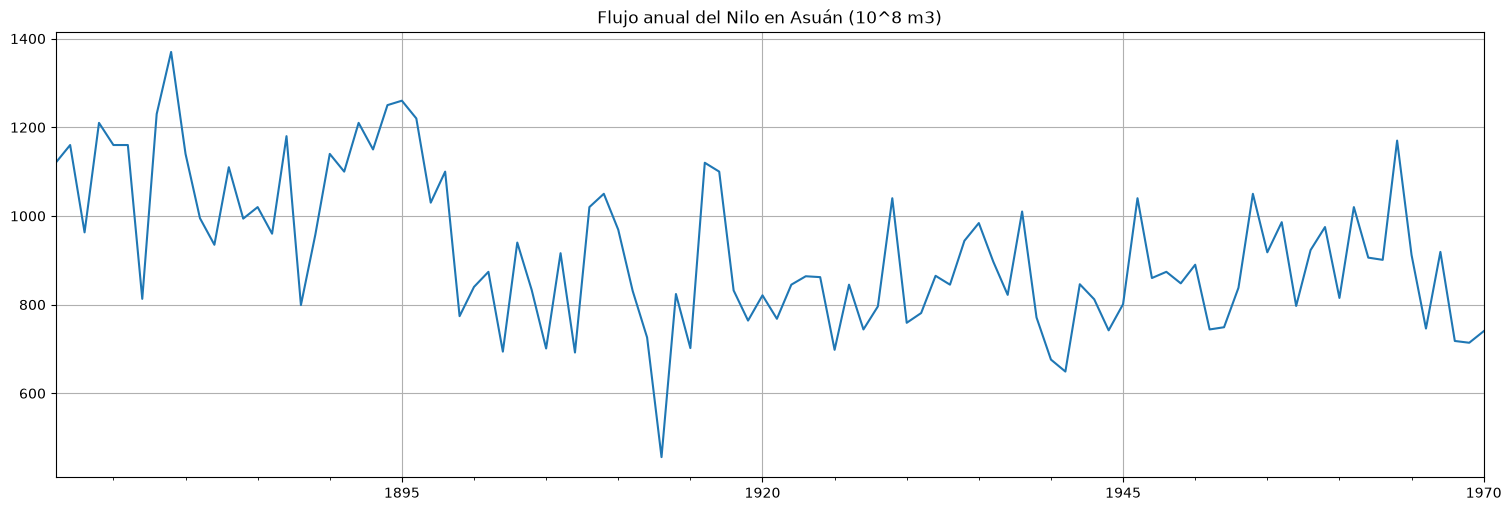

In [14]:
nile = sm.datasets.nile.load()
# Índice con frecuencia anual: statsmodels lo necesita para predecir con fechas
nile = pd.Series(nile['data']['volume'].values,
                 index=pd.period_range('1871', periods=len(nile['data']), freq='Y'))
nile.plot(title='Flujo anual del Nilo en Asuán (10^8 m3)');

### 2.1 ¿Es estacionaria?

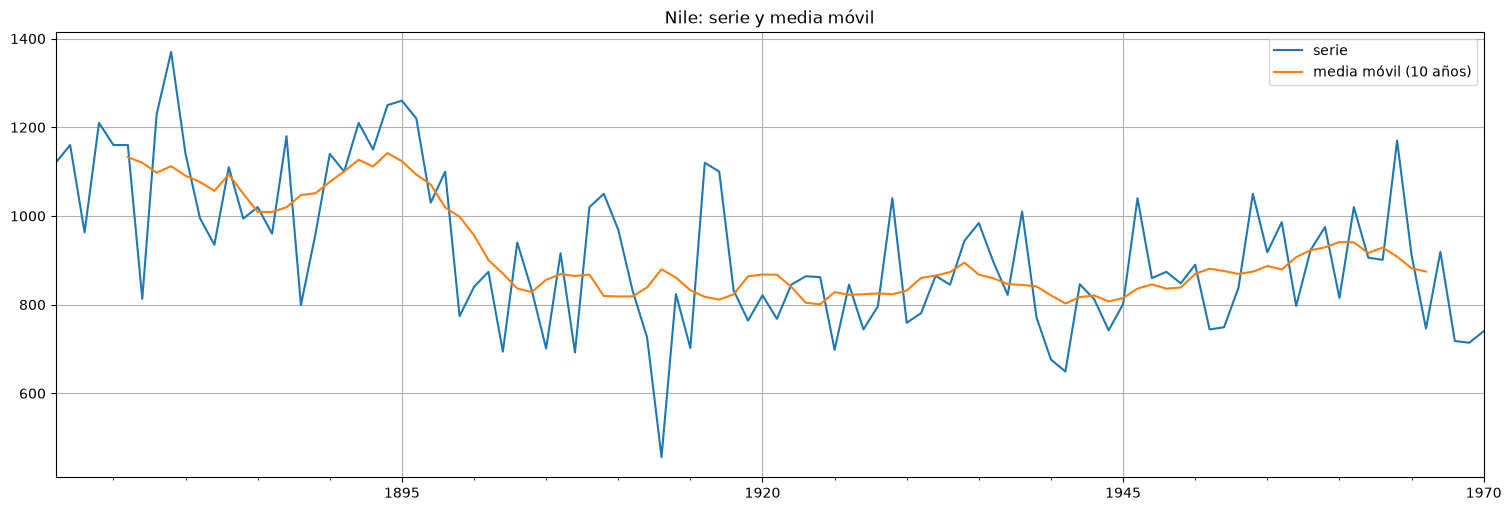

In [15]:
ax = nile.plot(label='serie')
nile.rolling(10, center=True).mean().plot(ax=ax, label='media móvil (10 años)')
ax.legend()
ax.set_title('Nile: serie y media móvil');

**💬 Discusión 2.1** — No hay tendencia sostenida ni estacionalidad (es una serie anual), y la varianza se ve estable. Se observa un **descenso de nivel alrededor de 1899** (coincide con la construcción de la primera represa de Asuán), por lo que la media no es estrictamente constante. Fuera de ese cambio de nivel, la serie oscila alrededor de una media fija: la tratamos como **aproximadamente estacionaria** a los efectos del ajuste ARMA (mencionar el cambio de nivel suma en la discusión).

### 2.2 ACF y PACF

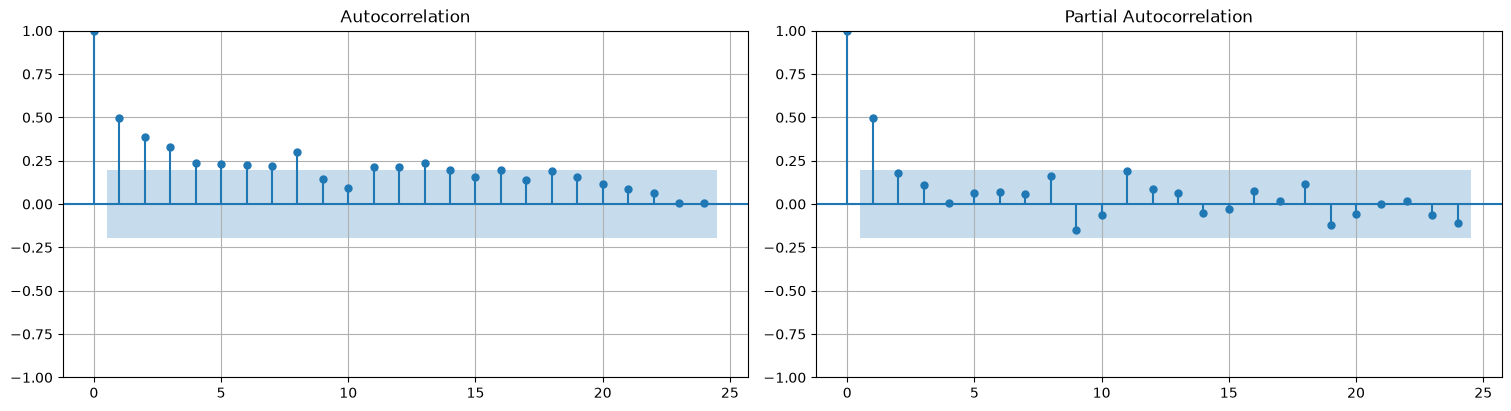

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(nile, lags=24, bartlett_confint=False, ax=axs[0])
plot_pacf(nile, lags=24, ax=axs[1]);

**💬 Discusión 2.2** — La **ACF decae de forma aproximadamente geométrica** (significativa en los primeros lags) y la **PACF se corta después del lag 1** (solo el primer lag claramente significativo). Ese patrón — ACF que decae + PACF que corta en p — es la firma de un **AR(1)**. Como alternativa razonable para comparar, probamos también un **ARMA(1,1)**.

### 2.3 Ajuste de modelos ARMA y comparación

In [17]:
m_ar1  = ARIMA(nile, order=(1, 0, 0)).fit()
m_arma = ARIMA(nile, order=(1, 0, 1)).fit()

print(f'AR(1)     : AIC = {m_ar1.aic:.1f}')
print(f'ARMA(1,1) : AIC = {m_arma.aic:.1f}')
best = m_arma if m_arma.aic < m_ar1.aic else m_ar1
print()
print(f'Elegido: {best.model.order}')

AR(1)     : AIC = 1285.9
ARMA(1,1) : AIC = 1282.1

Elegido: (1, 0, 1)


In [18]:
print(best.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -637.040
Date:                Sun, 05 Jul 2026   AIC                           1282.079
Time:                        16:55:10   BIC                           1292.500
Sample:                    12-31-1871   HQIC                          1286.297
                         - 12-31-1970                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        919.3505     47.441     19.379      0.000     826.368    1012.333
ar.L1          0.8610      0.082     10.442      0.000       0.699       1.023
ma.L1         -0.5176      0.147     -3.526      0.0

**💬 Discusión 2.3** — Se ajustan los dos candidatos y se comparan por **AIC** (menor = mejor; penaliza parámetros de más) y por la significancia de los coeficientes en el `summary`. En esta corrida: AR(1) AIC = 1285.9 vs **ARMA(1,1) AIC = 1282.1** → elegimos ARMA(1,1), con ar.L1 ≈ 0.86 y ma.L1 ≈ −0.52, ambos significativos. Frase tipo para el parcial: *"ambos modelos son plausibles según la ACF/PACF; el criterio AIC favorece al ARMA(1,1) y sus coeficientes son significativos, por lo que lo seleccionamos sujeto a que sus residuos queden limpios"*.

### 2.4 Análisis de residuos

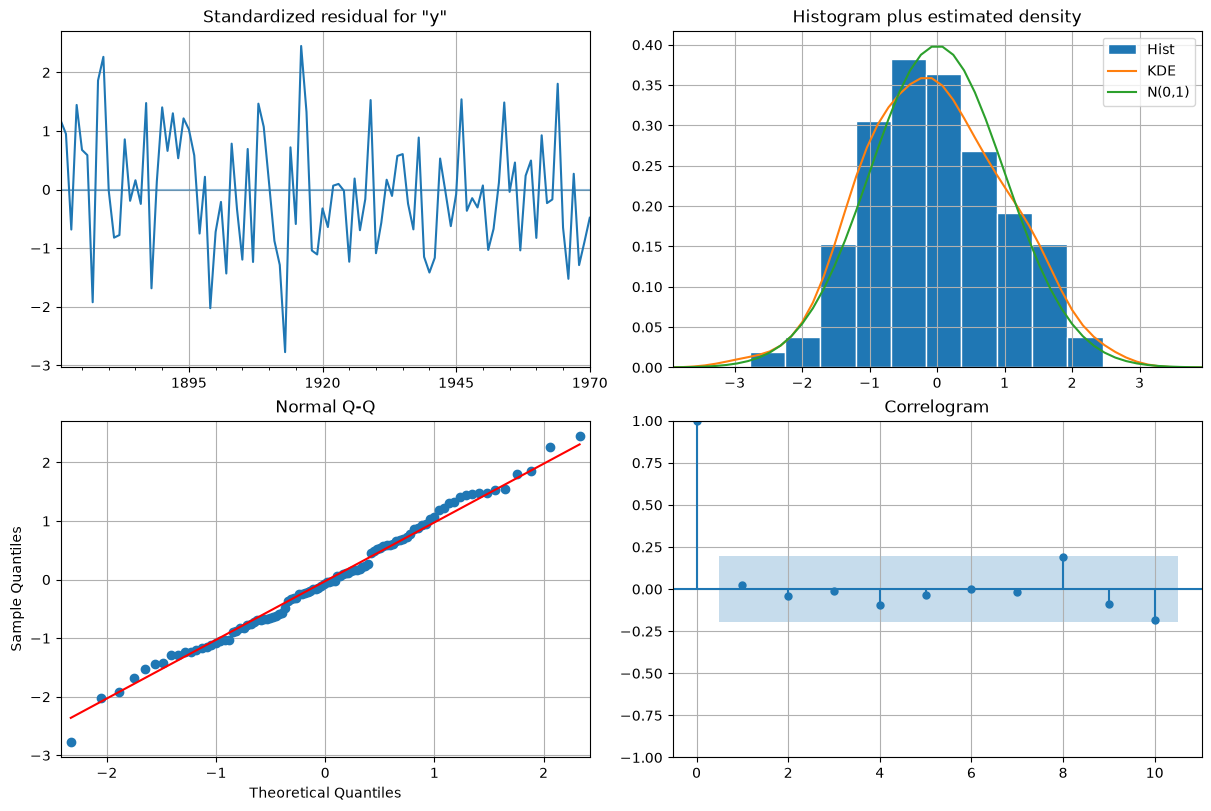

In [19]:
best.plot_diagnostics(figsize=(12, 8));

In [20]:
print(sm.stats.acorr_ljungbox(best.resid, lags=[10, 20]))

      lb_stat  lb_pvalue
10  10.141423   0.428175
20  14.755796   0.790206


**💬 Discusión 2.4** — Los residuos estandarizados oscilan alrededor de 0 sin patrón; el **correlograma de residuos queda dentro de las bandas** (sin autocorrelación remanente); el histograma y el QQ-plot son aproximadamente normales. El test de **Ljung-Box no rechaza** la hipótesis de ruido blanco (p-valores > 0.05). Conclusión: el modelo es adecuado — capturó la dependencia temporal.

### 2.5 Predicción a 5 años

In [21]:
fc = best.get_forecast(5)
pred = fc.predicted_mean
ci = fc.conf_int(alpha=0.05)
print(pd.DataFrame({'prediccion': pred, 'IC_inf': ci.iloc[:, 0], 'IC_sup': ci.iloc[:, 1]}))

      prediccion      IC_inf       IC_sup
1971  799.970685  524.130221  1075.811148
1972  816.564472  524.911432  1108.217511
1973  830.851724  528.008915  1133.694532
1974  843.153050  532.274881  1154.031219
1975  853.744493  537.041100  1170.447885


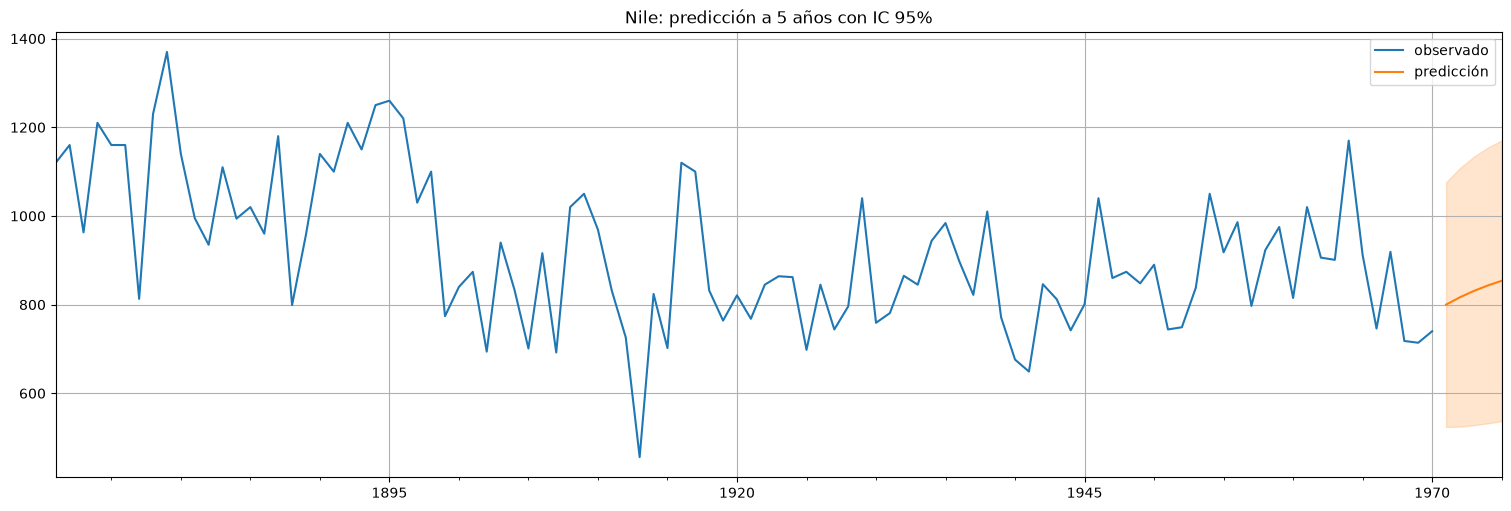

In [22]:
ax = nile.plot(label='observado')
pred.plot(ax=ax, label='predicción', color='C1')
plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color='C1', alpha=0.2)
ax.legend()
ax.set_title('Nile: predicción a 5 años con IC 95%');

**💬 Discusión 2.5** — La predicción parte del último valor observado y **converge rápidamente hacia la media del proceso** (comportamiento típico de un AR estacionario con |φ| < 1: la memoria se agota geométricamente). Los intervalos de confianza **se ensanchan con el horizonte y se estabilizan** en el ancho que corresponde a la varianza marginal del proceso.

---
## Ejercicio 3 — `co` → `rmort`: CCF y regresión con lag (Tipo C)

Series semanales de `lap` (Los Angeles, 1970–1979): x = nivel de CO, y = mortalidad respiratoria. Se pide: (1) CCF, (2) lag de máxima correlación, (3) regresión y_t = β₀ + β₁·x_{t−l}, (4) varianza explicada, (5) gráfico predicción vs observado, (6) residuos.

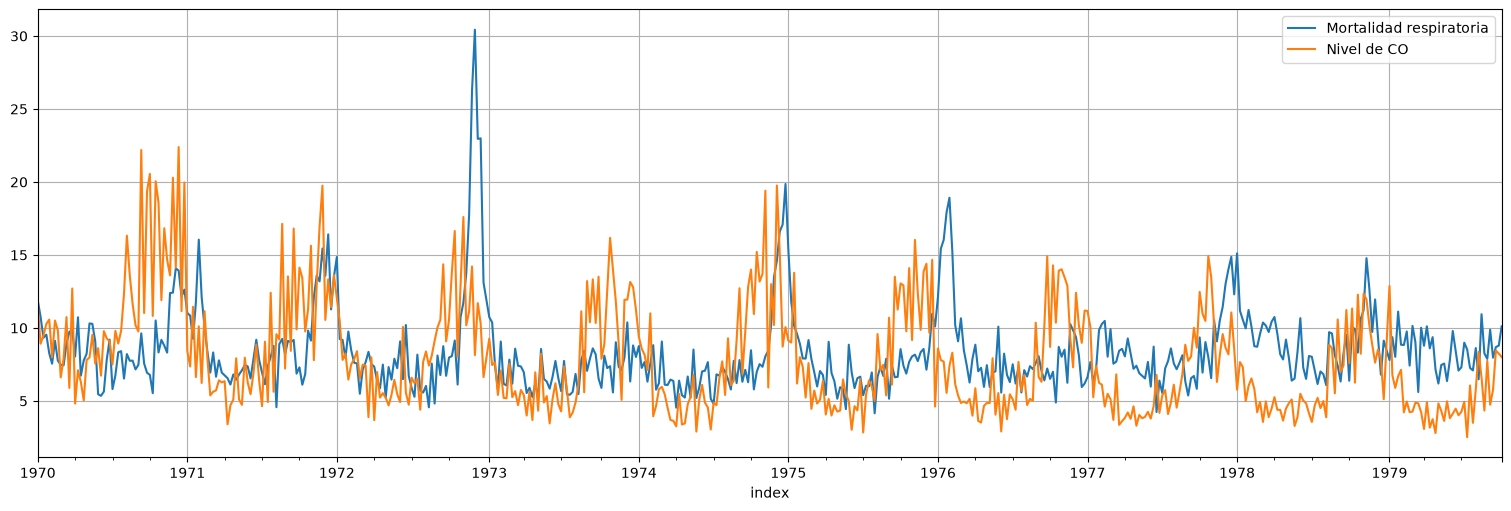

In [23]:
x = astsa.lap['co']       # nivel de CO (semanal)
y = astsa.lap['rmort']    # mortalidad respiratoria (semanal)

ax = y.plot(label='Mortalidad respiratoria')
x.plot(ax=ax, label='Nivel de CO')
ax.legend();

### 3.1 Correlación cruzada

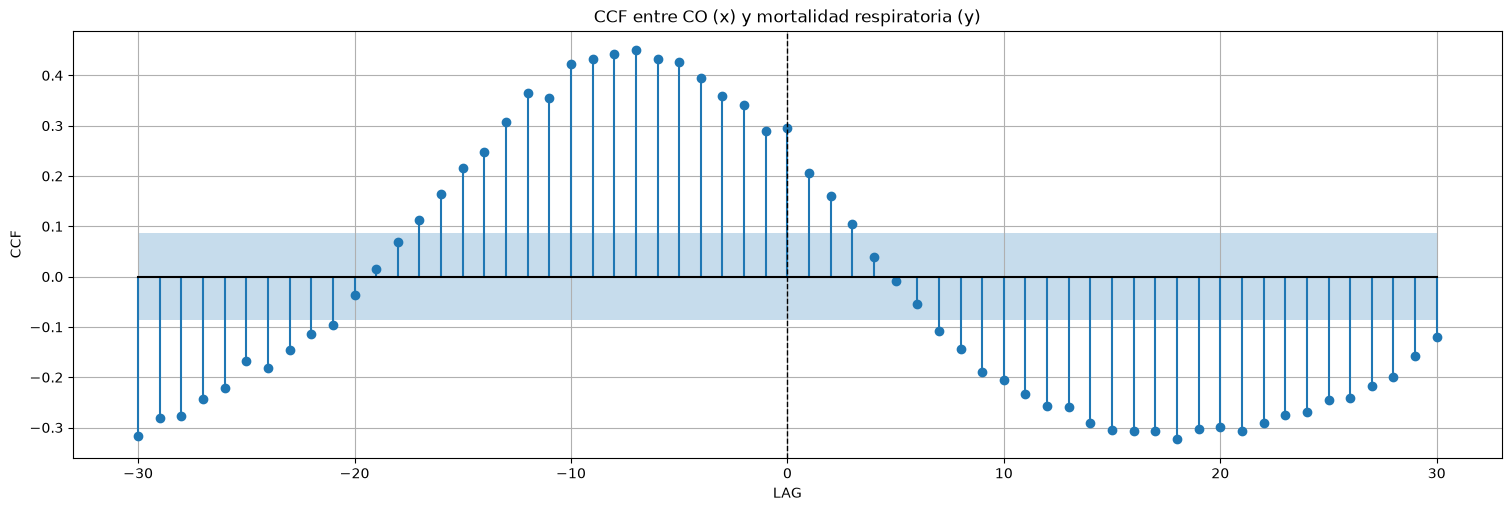

In [24]:
ccf(x, y, max_lag=30)
plt.title('CCF entre CO (x) y mortalidad respiratoria (y)');

**💬 Discusión 3.1** — Hay correlación cruzada claramente significativa (muy por fuera de la banda de confianza), con un bloque de correlaciones positivas concentrado de un lado del lag 0. Ambas series comparten además el ciclo anual (ambas suben en invierno), lo que infla las correlaciones a lags largos. Para decidir el lag puntual del modelo, en la parte siguiente lo calculamos numéricamente.

### 3.2 Lag de máxima correlación

In [25]:
# corr(y_t, x_{t-l}) para l = 0..12: ¿con cuántas semanas de retardo influye x en y?
cors = pd.Series({l: y.corr(x.shift(l)) for l in range(0, 13)})
print(cors)

l_opt = int(cors.idxmax())
print()
print(f'Lag óptimo: l = {l_opt} semanas | corr = {cors.max():.3f}')

0     0.295821
1     0.290191
2     0.341598
3     0.359201
4     0.396229
5     0.427900
6     0.435108
7     0.452350
8     0.445080
9     0.435299
10    0.425734
11    0.356829
12    0.367312
dtype: float64

Lag óptimo: l = 7 semanas | corr = 0.452


**💬 Discusión 3.2** — Recorremos corr(y_t, x_{t−l}) para l = 0…12 y nos quedamos con el máximo: **l = 7 semanas** (corr ≈ 0.45), consistente con el bloque de correlaciones positivas que se ve en la CCF. Interpretación: **el efecto del CO sobre la mortalidad respiratoria aparece con ~7 semanas de retardo** — x "adelanta" a y, por eso tiene sentido predecir y con el pasado de x.

### 3.3 Regresión con la serie laggeada

In [26]:
datos = pd.DataFrame({'y': y, 'xlag': x.shift(l_opt)}).dropna()
fit_lag = ols('y ~ xlag', data=datos).fit()
print(fit_lag.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.6412      0.267     21.136      0.000       5.117       6.166
xlag           0.3444      0.030     11.330      0.000       0.285       0.404


**💬 Discusión 3.3** — β₁ es positivo y significativo (p < 0.001): a mayor nivel de CO hace l semanas, mayor mortalidad respiratoria hoy. Ojo operativo: `shift(l)` corre la serie y genera `NaN` al principio — el `dropna()` alinea las dos series antes de ajustar.

### 3.4 Varianza explicada

In [27]:
print(f'R2 = {fit_lag.rsquared:.3f}  ->  el modelo explica {100*fit_lag.rsquared:.1f}% de la varianza de y')

R2 = 0.205  ->  el modelo explica 20.5% de la varianza de y


**💬 Discusión 3.4** — En regresión simple R² = corr²: acá 0.45² ≈ 0.205, coherente con la correlación hallada en 3.2 (vale la pena señalarlo). El modelo explica ~20% de la varianza de la mortalidad; el resto queda sin explicar — estacionalidad propia, temperatura, otros contaminantes.

### 3.5 Predicción del modelo vs observado

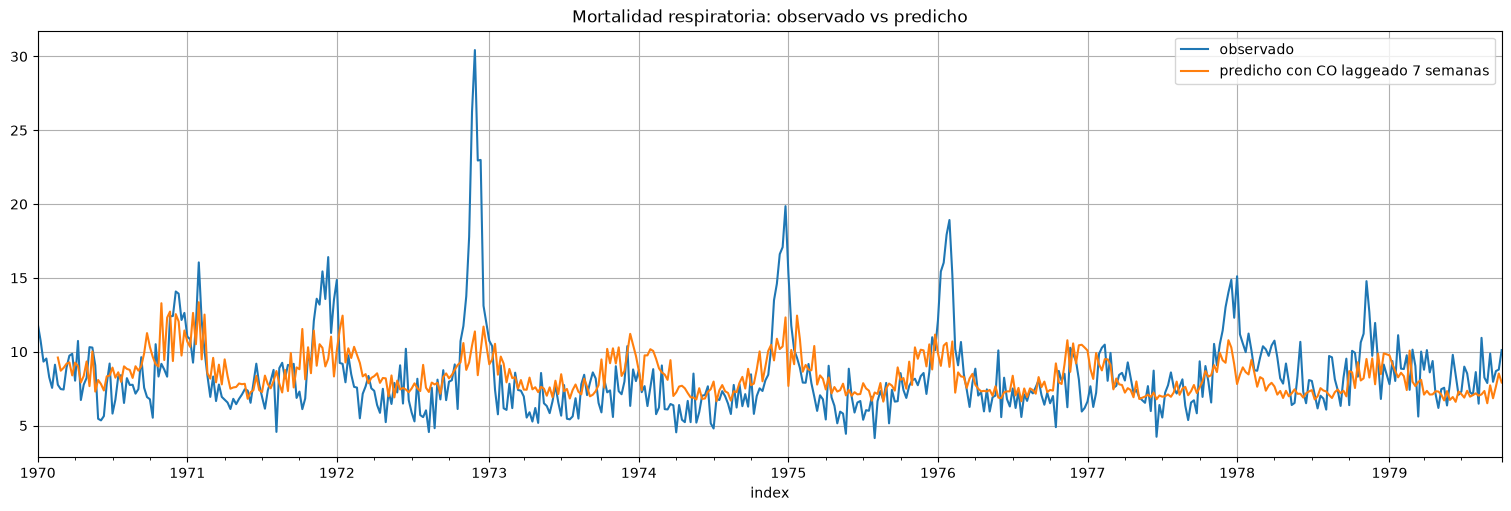

In [28]:
ax = y.plot(label='observado')
fit_lag.fittedvalues.plot(ax=ax, label=f'predicho con CO laggeado {l_opt} semanas')
ax.legend()
ax.set_title('Mortalidad respiratoria: observado vs predicho');

**💬 Discusión 3.5** — La predicción arranca l semanas después del inicio (se pierden las primeras observaciones por el lag, como advierte el enunciado). El modelo sigue el nivel y parte del ciclo de la serie, pero suaviza los picos: con un solo regresor no alcanza para reproducir los extremos.

### 3.6 Residuos: ¿queda información?

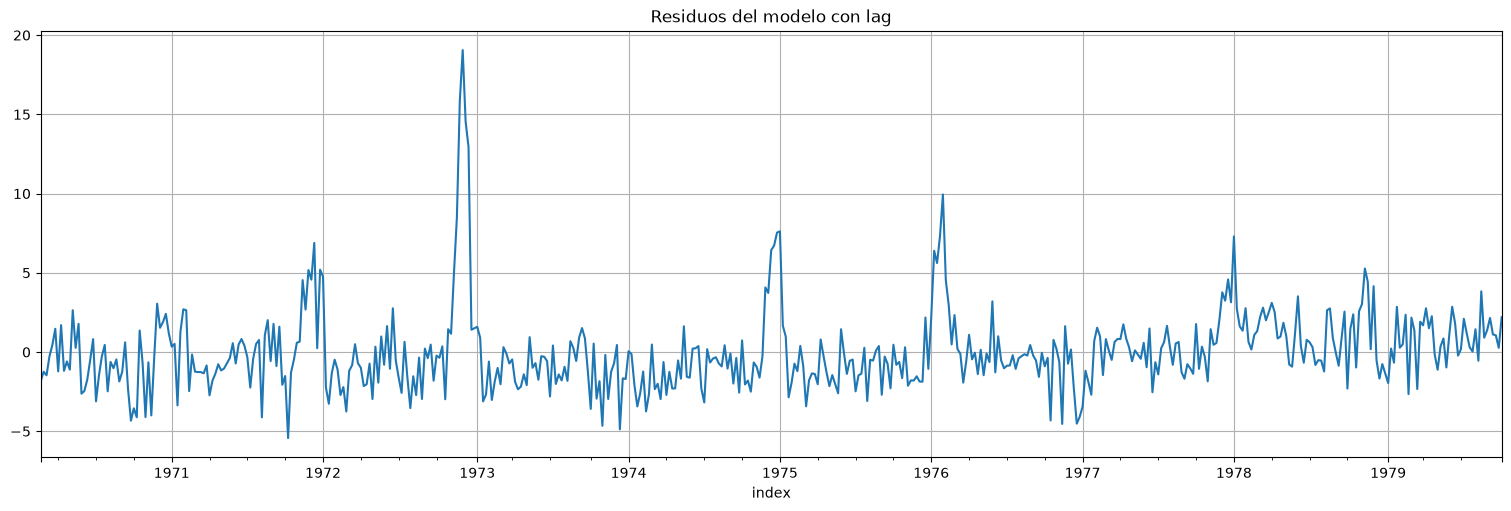

In [29]:
res3 = fit_lag.resid
res3.plot(title='Residuos del modelo con lag');

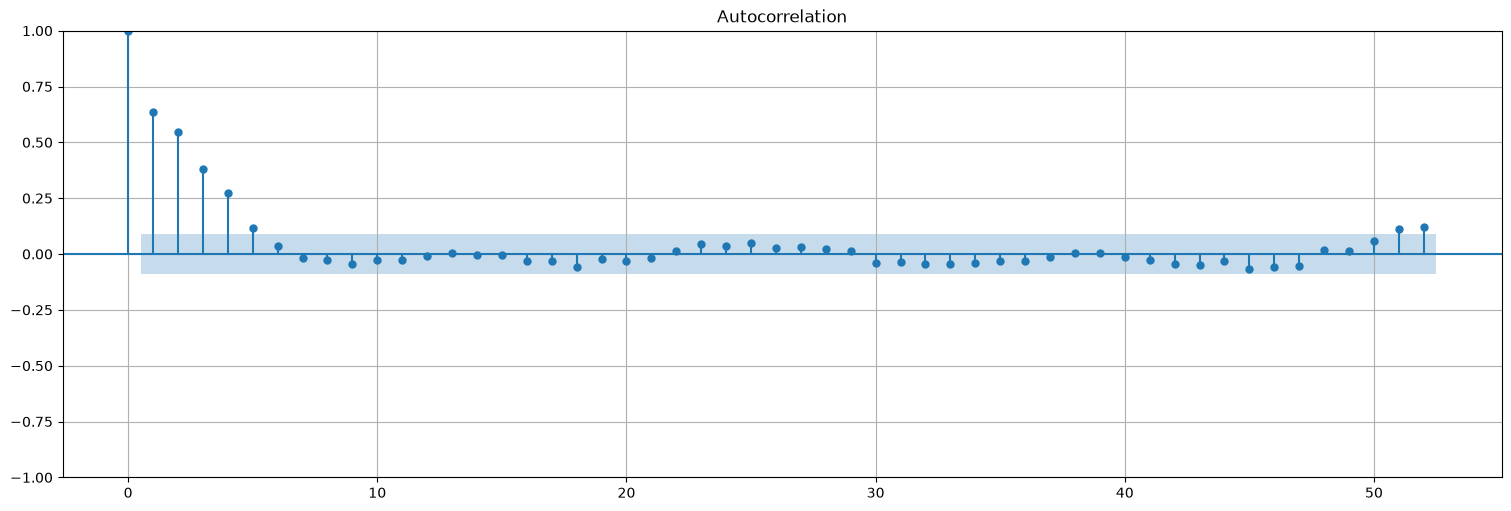

In [30]:
plot_acf(res3, lags=52, bartlett_confint=False);

**💬 Discusión 3.6** — Los residuos **no son ruido blanco**: la ACF muestra correlación de corto plazo y una onda con período ≈ 52 semanas (estacionalidad anual de la mortalidad que el CO laggeado no captura del todo). **Sí queda información por ajustar**: se podría agregar tendencia y componentes estacionales (como en el Ejercicio 1), otros regresores (temperatura, partículas) o modelar el residuo con un ARMA.

---
## Moraleja del parcial 2022

- **Ej. 1 = receta Tipo A**: tendencia → ¿mejora la cuadrática? → periodograma de residuos → armónicos/dummies → ACF de residuos finales.
- **Ej. 2 = receta Tipo B**: mirar la serie → ACF/PACF → 2 candidatos → AIC + significancia → diagnóstico → `get_forecast` con IC.
- **Ej. 3 = receta Tipo C**: CCF → lag óptimo (scan de correlaciones) → `shift` + `dropna` + `ols` → R² → gráfico → ACF de residuos.
- En **todas** las partes: 2–3 oraciones de interpretación. El código es lo rápido; el comentario es lo que puntúa.